In [4]:
from pathlib import Path
import mne

# Change this to your actual Sleep-EDF dataset location
DATA_DIR = Path(r"../../Dataset/sleep-edf-database-expanded-1.0.0/sleep-edf-database-expanded-1.0.0")

psg_path = DATA_DIR / "sleep-cassette" / "SC4001E0-PSG.edf"

raw = mne.io.read_raw_edf(
    psg_path,
    preload=False,
    verbose=True
)

print(raw)

Extracting EDF parameters from ..\..\Dataset\sleep-edf-database-expanded-1.0.0\sleep-edf-database-expanded-1.0.0\sleep-cassette\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~10 KiB, data not loaded>


C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_114448\3151352319.py:9: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_114448\3151352319.py:9: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_114448\3151352319.py:9: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


In [5]:
print("\n--- BASIC INFORMATION ---")
print("Number of channels:", len(raw.ch_names))
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Recording duration:", raw.times[-1], "seconds")
print("Recording duration:", raw.times[-1] / 3600, "hours")

print("\n--- CHANNELS ---")
for i, channel in enumerate(raw.ch_names):
    print(i, channel)


--- BASIC INFORMATION ---
Number of channels: 7
Sampling frequency: 100.0 Hz
Recording duration: 79499.99 seconds
Recording duration: 22.083330555555555 hours

--- CHANNELS ---
0 EEG Fpz-Cz
1 EEG Pz-Oz
2 EOG horizontal
3 Resp oro-nasal
4 EMG submental
5 Temp rectal
6 Event marker


In [6]:
hypnogram_path = DATA_DIR / "sleep-cassette" / "SC4001EC-Hypnogram.edf"

annotations = mne.read_annotations(hypnogram_path)

print(annotations)

<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>


In [7]:
print("\n--- ANNOTATIONS ---")
print("Number of annotations:", len(annotations))

for onset, duration, description in zip(
    annotations.onset,
    annotations.duration,
    annotations.description
):
    print(
        f"Onset: {onset:8.2f}s | "
        f"Duration: {duration:6.2f}s | "
        f"Stage: {description}"
    )


--- ANNOTATIONS ---
Number of annotations: 154
Onset:     0.00s | Duration: 30630.00s | Stage: Sleep stage W
Onset: 30630.00s | Duration: 120.00s | Stage: Sleep stage 1
Onset: 30750.00s | Duration: 390.00s | Stage: Sleep stage 2
Onset: 31140.00s | Duration:  30.00s | Stage: Sleep stage 3
Onset: 31170.00s | Duration:  30.00s | Stage: Sleep stage 2
Onset: 31200.00s | Duration: 150.00s | Stage: Sleep stage 3
Onset: 31350.00s | Duration:  30.00s | Stage: Sleep stage 4
Onset: 31380.00s | Duration:  60.00s | Stage: Sleep stage 3
Onset: 31440.00s | Duration:  60.00s | Stage: Sleep stage 4
Onset: 31500.00s | Duration:  30.00s | Stage: Sleep stage 3
Onset: 31530.00s | Duration: 120.00s | Stage: Sleep stage 4
Onset: 31650.00s | Duration:  30.00s | Stage: Sleep stage 3
Onset: 31680.00s | Duration: 120.00s | Stage: Sleep stage 4
Onset: 31800.00s | Duration:  30.00s | Stage: Sleep stage W
Onset: 31830.00s | Duration:  60.00s | Stage: Sleep stage 3
Onset: 31890.00s | Duration:  60.00s | Stage: Slee

Using matplotlib as 2D backend.


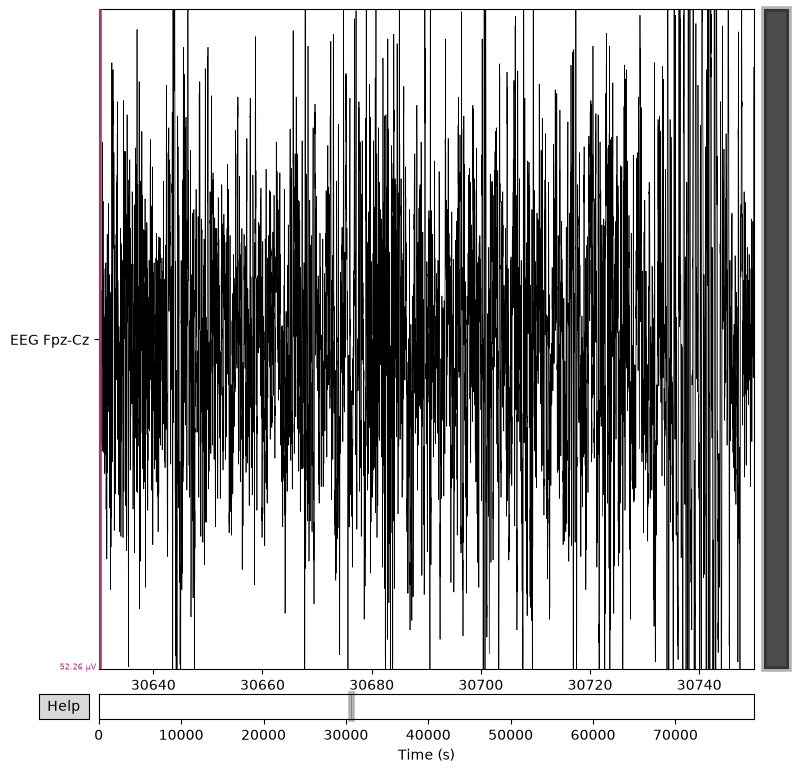

In [8]:
import matplotlib.pyplot as plt

# Select the Fpz-Cz EEG channel
eeg = raw.copy().pick(["EEG Fpz-Cz"])

# Plot 2 minutes beginning at the first scored sleep epoch
start_time = 30630
duration = 120

eeg.plot(
    start=start_time,
    duration=duration,
    scalings="auto",
    title="SC4001 - EEG Fpz-Cz around Sleep Onset"
)

plt.show()

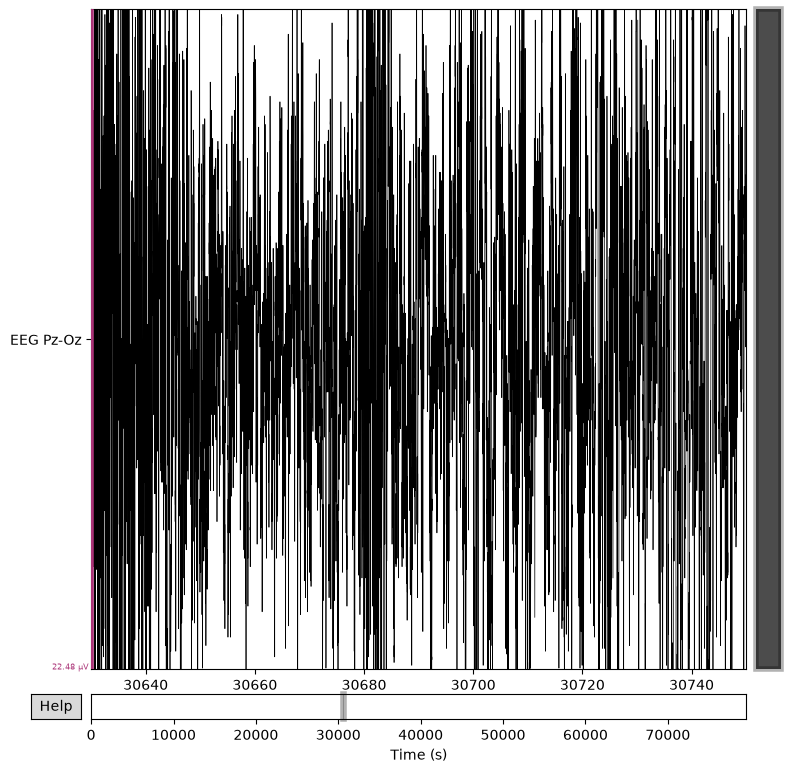

In [9]:
eeg2 = raw.copy().pick(["EEG Pz-Oz"])

eeg2.plot(
    start=30630,
    duration=120,
    scalings="auto",
    title="SC4001 - EEG Pz-Oz around Sleep Onset"
)

plt.show()

C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_114448\1843798298.py:1: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)
C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_114448\1843798298.py:3: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot(
C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_114448\1843798298.py:3: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot(


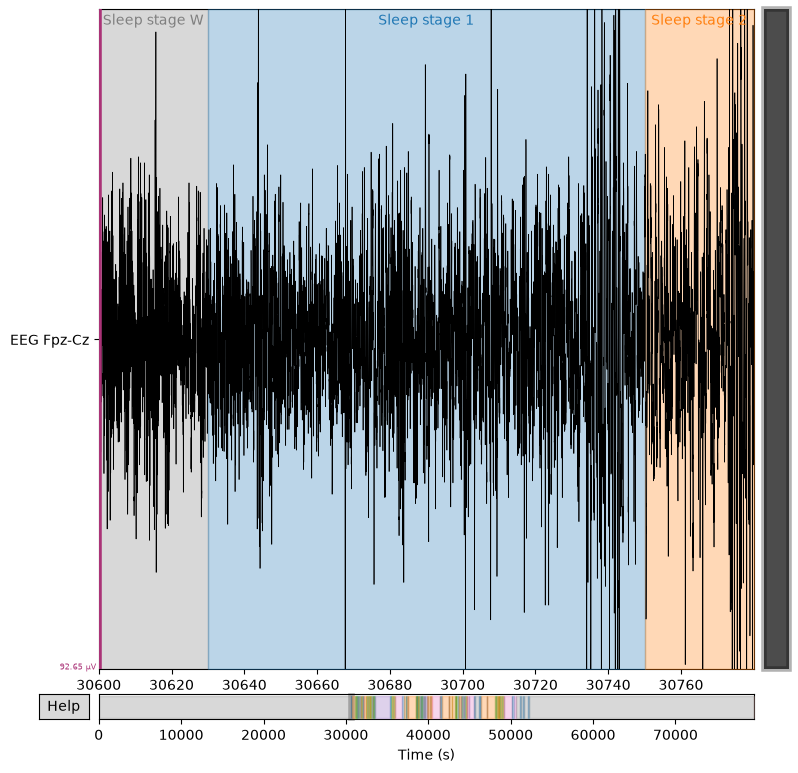

In [10]:
raw.set_annotations(annotations)

raw.plot(
    picks=["EEG Fpz-Cz"],
    start=30600,
    duration=180,
    scalings="auto",
    title="SC4001 - EEG with Sleep-Stage Annotations"
)

plt.show()

In [11]:
from collections import Counter

stage_counts = Counter(annotations.description)

for stage, count in stage_counts.items():
    print(f"{stage}: {count}")

Sleep stage W: 12
Sleep stage 1: 24
Sleep stage 2: 40
Sleep stage 3: 48
Sleep stage 4: 23
Sleep stage R: 6
Sleep stage ?: 1
